In [ ]:
!pip install vitaldb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.9/68.9 kB 2.6 MB/s eta 0:00:00


In [ ]:
import vitaldb
import pandas as pd #to load the different files in the dataset
import numpy as np
import matplotlib.pyplot as plt
#load clinical data
clinical_data = pd.read_csv('https://physionet.org/files/vitaldb/1.0.0/clinical_data.csv')
display(clinical_data)


,caseid,subjectid,casestart,caseend,anestart,aneend,opstart,opend,adm,dis,...,intraop_colloid,intraop_ppf,intraop_mdz,intraop_ftn,intraop_rocu,intraop_vecu,intraop_eph,intraop_phe,intraop_epi,intraop_ca
0,1,5955,0,11542,-552,10848.0,1668,10368,-236220,627780,...,0,120,0.0,100,70,0,10,0,0,0
1,2,2487,0,15741,-1039,14921.0,1721,14621,-221160,1506840,...,0,150,0.0,0,100,0,20,0,0,0
2,3,2861,0,4394,-590,4210.0,1090,3010,-218640,40560,...,0,0,0.0,0,50,0,0,0,0,0
3,4,1903,0,20990,-778,20222.0,2522,17822,-201120,576480,...,0,80,0.0,100,100,0,50,0,0,0
4,5,4416,0,21531,-1009,22391.0,2591,20291,-67560,3734040,...,0,0,0.0,0,160,0,10,900,0,2100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6383,6384,5583,0,15248,-260,15640.0,2140,14140,-215340,648660,...,0,150,0.0,0,90,0,20,0,0,0
6384,6385,2278,0,20643,-544,20996.0,2396,19496,-225600,1675200,...,0,100,0.0,0,100,0,25,30,0,300
6385,6386,4045,0,19451,-667,19133.0,3533,18233,-200460,836340,...,0,70,0.0,0,130,0,10,0,0,0
6386,6387,5230,0,12025,-550,12830.0,1730,11030,-227760,377040,...,0,120,0.0,0,50,0,0,0,0,0


In [ ]:
colorectal_data = clinical_data[clinical_data['optype'] == 'Colorectal']
display(colorectal_data)

,caseid,subjectid,casestart,caseend,anestart,aneend,opstart,opend,adm,dis,...,intraop_colloid,intraop_ppf,intraop_mdz,intraop_ftn,intraop_rocu,intraop_vecu,intraop_eph,intraop_phe,intraop_epi,intraop_ca
0,1,5955,0,11542,-552,10848.0,1668,10368,-236220,627780,...,0,120,0.0,100,70,0,10,0,0,0
14,15,4645,0,3510,-933,3207.0,1407,2907,-150360,22440,...,0,0,0.0,0,0,0,0,0,0,0
17,18,4091,0,4416,-823,3977.0,1277,3077,-407580,197220,...,0,0,0.0,0,30,0,10,0,0,0
20,21,5683,0,12690,-373,12647.0,3047,11447,-311640,465960,...,0,100,0.0,100,100,0,10,0,0,0
29,30,3196,0,11123,-259,10781.0,2081,10181,-288600,402600,...,0,0,0.0,0,90,0,5,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6355,6356,5018,0,22116,-1191,21609.0,2109,20409,-201540,835260,...,0,100,0.0,100,140,0,15,0,0,0
6357,6358,5173,0,18896,-37,18863.0,3563,17963,-287100,404100,...,0,0,0.0,0,80,0,55,0,0,0
6359,6360,4777,0,21306,-440,20200.0,2440,19000,-374580,1094220,...,500,100,0.0,0,100,0,15,0,0,600
6376,6377,586,0,5624,-242,6058.0,1798,4858,-221940,296460,...,0,100,0.0,100,50,0,0,0,0,0


In [ ]:
essential_data = colorectal_data[['caseid', 'aneend', 'dis', 'age']]
essential_data = essential_data.reset_index(drop=True)
display(essential_data)

,caseid,aneend,dis,age
0,1,10848.0,627780,77
1,15,3207.0,22440,56
2,18,3977.0,197220,77
3,21,12647.0,465960,69
4,30,10781.0,402600,59
...,...,...,...,...
1345,6356,21609.0,835260,65
1346,6358,18863.0,404100,74
1347,6360,20200.0,1094220,41
1348,6377,6058.0,296460,31


In [ ]:
essential_data['length_stay_days'] = 0 #generates a new empty column
essential_data.drop(columns=['length_stay'], inplace=True)
display(essential_data)

,caseid,aneend,dis,age,length_stay_days
0,1,10848.0,627780,77,0
1,15,3207.0,22440,56,0
2,18,3977.0,197220,77,0
3,21,12647.0,465960,69,0
4,30,10781.0,402600,59,0
...,...,...,...,...,...
1345,6356,21609.0,835260,65,0
1346,6358,18863.0,404100,74,0
1347,6360,20200.0,1094220,41,0
1348,6377,6058.0,296460,31,0


In [ ]:
for i in range (0,len(essential_data)+1):
  essential_data['length_stay_days'] = (essential_data['dis']-essential_data['aneend'])/86400
display(essential_data)


,caseid,aneend,dis,age,length_stay_days
0,1,10848.0,627780,77,7.140417
1,15,3207.0,22440,56,0.222604
2,18,3977.0,197220,77,2.236609
3,21,12647.0,465960,69,5.246678
4,30,10781.0,402600,59,4.534942
...,...,...,...,...,...
1345,6356,21609.0,835260,65,9.417257
1346,6358,18863.0,404100,74,4.458762
1347,6360,20200.0,1094220,41,12.430787
1348,6377,6058.0,296460,31,3.361134


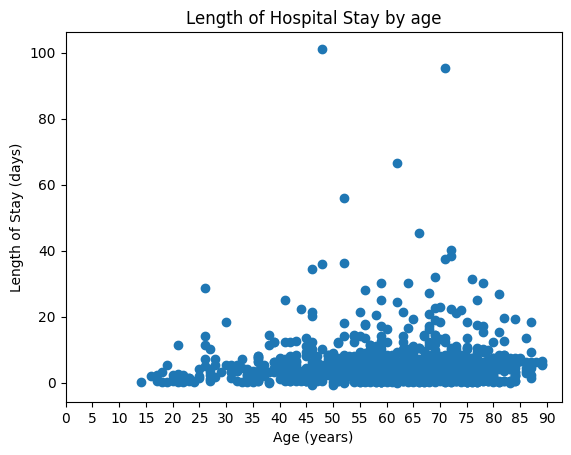

In [ ]:
essential_data['age'] = pd.to_numeric(essential_data['age'], errors='coerce') #convert age column from str to int
plt.scatter(essential_data['age'], essential_data['length_stay_days'])
plt.xlabel('Age (years)')
plt.ylabel('Length of Stay (days)')
plt.title('Length of Hospital Stay by age')
plt.xticks(np.arange(0, essential_data['age'].max() + 5, 5))
plt.show()

,caseid,aneend,dis,age,length_stay_days
0,1,10848.0,627780,77.0,7.140417
1,43,14859.0,644280,64.0,7.284965
2,116,13158.0,648000,64.0,7.347708
3,133,9447.0,648480,61.0,7.396215
4,192,10103.0,811740,59.0,9.278206
...,...,...,...,...,...
228,6300,5330.0,822840,59.0,9.461921
229,6317,15996.0,881820,69.0,10.021111
230,6356,21609.0,835260,65.0,9.417257
231,6360,20200.0,1094220,41.0,12.430787


Text(0.5, 1.0, 'Length of Hospital Stay by age')

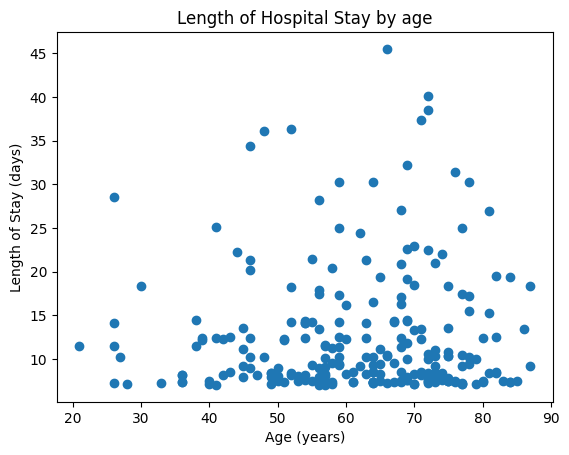

In [ ]:
#We decided to keep patients with length pf stay > 7 days and under 50 days
essential_data = essential_data[essential_data['length_stay_days'] < 50]
essential_data = essential_data[essential_data['length_stay_days'] > 7]
essential_data = essential_data.reset_index(drop=True)
display(essential_data)
# New plot
plt.scatter(essential_data['age'], essential_data['length_stay_days'])
plt.xlabel('Age (years)')
plt.ylabel('Length of Stay (days)')
plt.title('Length of Hospital Stay by age')